[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/garrygu/newegg-ai-workshop/blob/main/lv1-beginner-v2/Session%206/Session_6_The_Ultimate_AI_Game_Student_v2.ipynb)


# 🚀 Session 6 — The Ultimate AI Game (Student)

Welcome to the Grand Finale! 🎉

So far, you’ve built an AI that can recognize images and a game loop. But today, we elevate it to the next level!

Today, we will:
1. **The Real Brain**: Replace the file-name cheating with your actual Neural Network from Session 3.
2. **The Dynamic Soul**: Use a real Large Language Model (LLM) to give your AI a dynamic personality.
3. **Give It Voice**: Make the AI actually SPEAK to you using Text-to-Speech.
4. **The Arcade Interface**: Put everything into a beautiful Web UI using Gradio!


In [ ]:
# 🛠️ Setup: Install required libraries and fix version conflicts

# gtts (Google Text-to-Speech): 🗣️ The Vocal Chords. This tool takes the words the AI writes and turns them into an audio file. 
# gradio: 📱 The Game Screen: gradio lets us build a real "Web App" with buttons, image upload boxes, and sliders.
# openai: 🧠 The Personality Brain: It’s what allows our game to "think" of creative and funny responses.
# typer & click: ⚙️ The Secret Gears: These are "utility" tools. They help Python manage all the settings and commands behind the scenes.
!pip install --quiet --upgrade gtts typer click gradio openai

# ⚠️ IMPORTANT: In Colab, you MUST restart the session after installing libraries
from IPython.display import clear_output, display, HTML
clear_output()
display(HTML("""
<div style='background-color: #ffe6e6; padding: 15px; border-radius: 5px; border: 1px solid #ff4d4d;'>
    <h3 style='color: #cc0000; margin-top: 0;'>⚠️ Action Required: Restart Runtime</h3>
    <p>Libraries (including OpenAI SDK) have been updated. To avoid <b>ImportErrors</b>, you <b>must</b> restart the session:</p>
    <ol>
        <li>Go to the top menu: <b>Runtime</b> &rarr; <b>Restart session</b></li>
        <li>Then run the cells again starting from the imports!</li>
    </ol>
</div>
"""))


In [ ]:
# 📦 Let's import all our superpowers in one place!
import json
import random
from pathlib import Path

# Superpower 1: AI Vision
import torch
import torch.nn as nn
from PIL import Image
from torchvision import models, transforms

# Superpower 2: LLM Brains (OpenAI)
from openai import OpenAI

# Superpower 3: Voice AI
from gtts import gTTS
import librosa

# Superpower 4: Web UI
import gradio as gr

print("✅ Superpowers loaded!")


## Step 1 — Load Your Game Memory
Let's load what you saved in previous sessions.

In [ ]:
settings_path = Path("session_data/game_settings.json")

if settings_path.exists():
    with open(settings_path, "r", encoding="utf-8") as f:
        settings = json.load(f)
else:
    settings = {"classes": ["cat", "dog"], "num_classes": 2, "personality": "sassy"}

classes = settings["classes"]
num_classes = settings.get("num_classes", len(classes))
personality = settings.get("personality", "sassy")

print("Labels:", classes)
print("Personality to use:", personality)


## Step 2 — The Real AI Brain (Vision)
Load your `ResNet18` model from Session 3. If you don't have one, it will load the default.

In [ ]:
from hpack import huffman_constants
model_path = Path("models/classifier.pt")

# ResNet18 is a world-famous AI architecture. When we say weights=None, we are getting a brand-new, empty brain. 
# It has the structure of an AI, but it doesn't know anything yet. 
# It's like a fresh notebook with no writing in it—ready for us to fill it with our saved memories.
model = models.resnet18(weights=None)

# Imagine you found a giant robot that was built to sort 1,000 different types of candy. 
# It has 512 wires coming from its eyes, but its control panel has 1,000 buttons.
# In our game, we only have 2 types of candy. If we don't change the control panel, the robot will get confused and try to find candy that doesn't exist!
# This line of code says: "Keep the 512 wires (in_features) that tell us what the candy looks like, but rip out the 1,000-button control panel and replace it with a simple 2-button panel (num_classes)."
# Now, our AI brain is perfectly sized for our game!
model.fc = nn.Linear(model.fc.in_features, num_classes)

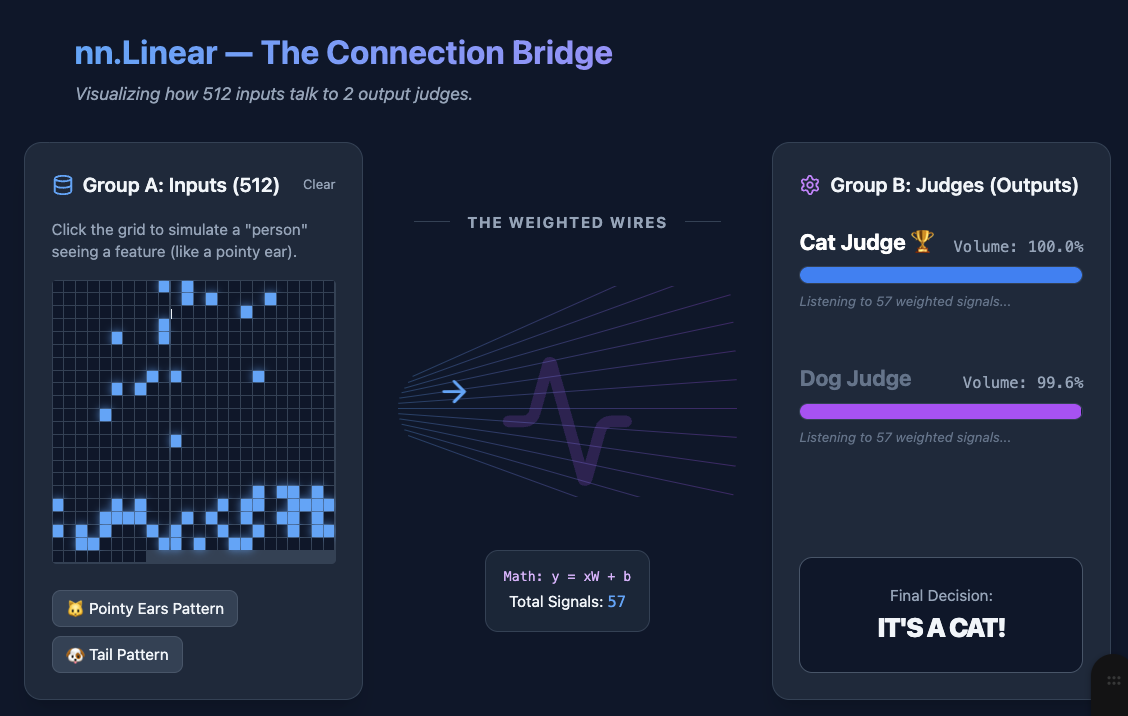

In [ ]:
# Think of the Model as a USB Drive and a Video Game:
# The model (we built earlier) is the Game Console. It's ready to play, but has no game inside.
# torch.load is like finding the Game Disc on your shelf.
# load_state_dict is like Inserting the Disc into the console.
if model_path.exists():
    # Unpack the file. Inside are all the Weights (the tilts of the pegs we talked about) that the AI learned.
    state = torch.load(model_path, map_location="cpu")

    # The Memory Injection
    # This is the most exciting part! We take the knowledge we just unpacked and pour it into our empty brain.
    # Before this line: The brain was like a student on the first day of school who knows nothing.
    # After this line: The brain suddenly "remembers" everything it learned in Session 3. It now knows exactly how to tell a cat from a dog!
    model.load_state_dict(state)
    print("✅ Real AI Brain Loaded!")
else:
    print("⚠️ No trained model found, using random guesses.")S

# The "Exam Mode" Switch
# We are telling the AI: "Stop practicing and start playing the game!
model.eval()

In [ ]:
# Imagine you are a Chef, and someone brings you a giant, unpeeled potato.
# Resize is like chopping the potato so it's the right size for your pot.
# ToTensor is like peeling the potato so it's ready to be cooked.
# By the time the "Transform" is done, the image is "Clean" and ready for the AI to "Eat" (Process)! 🥗

# The Assembly Line: This is just a way to link the steps together. It says: "First, resize the photo. Then, translate it into numbers. Do these in order every time!"
transform = transforms.Compose([
    # The Perfect Fit: Our AI brain (ResNet18) was designed to see photos that are exactly 224 pixels wide and 224 pixels tall.
    transforms.Resize((224, 224)),
    # The Math Translator: "Tensor" is just a fancy AI word for a Grid of Numbers. This line takes the visual picture and translates it into a big list of numbers that the AI can do math with.
    transforms.ToTensor(),
])

# It’s the code that takes an actual picture and gives us a word as an answer.
def predict_image(image):
    """Takes a PIL Image and returns the label name."""
    image = image.convert("RGB")  ## Standard Colors: This line makes sure the AI only sees standard Red, Green, and Blue colors.
    x = transform(image).unsqueeze(0) ## unsqueeze(0): AI likes to process things in Groups (called batches). Even though we only have one photo, we have to "Box it up" and tell the AI: "Here is a group... that only has one photo in it!"
    with torch.no_grad(): ## Quiet Mode: This tells the computer to stop taking notes
        logits = model(x)  ## The AI's "Scream": The model looks at the box and "screams" its raw numbers. It might say: "I feel 10 points for Cat and -5 points for Dog!"
        probs = torch.softmax(logits, dim=1)[0] ## The Percentage Maker: Softmax is a cool math tool that turns those "screams" into nice percentages. Now the AI says: "I am 99% sure it's a Cat and 1% sure it's a Dog."
    best_idx = int(torch.argmax(probs).item()) ## Picking the Winner: This simply looks at the percentages and grabs the highest one.
    return classes[best_idx] ## The Human Word: Computers love numbers (like 0), but humans love words (like "Cat"). This final line translates the AI's "Winning Number" back into a word that we can print on the screen!

## Step 3 — The Dynamic Soul (Prompt Engineering)
Instead of a boring list of responses, we connect to Google Gemini to write unique, creative responses on the fly!
- Insert your API key provided by your teacher.

In [ ]:
# Paste your API key here 🔑
OPENAI_API_KEY = "YOUR_API_KEY_HERE"



# Create the OpenAI AI Model instance
try:
    client = OpenAI(api_key=OPENAI_API_KEY)
except:
    client = None
    print("You need to put in your API key!")


In [ ]:
def get_ai_reaction(is_correct, ai_guess, player_guess, game_personality):
    """
    Uses OpenAI to generate a fun, creative response!
    """
    if OPENAI_API_KEY == "YOUR_API_KEY_HERE":
        return f"{game_personality.upper()}: You need an API key to talk to me!"
        
    status = "correct" if is_correct else "wrong"
    
    # This is Prompt Engineering!
    prompt = f"""
    You are a game show host with a {game_personality} personality.
    The player just guessed '{player_guess}'. The true answer was '{ai_guess}'.
    The player was {status}.
    Keep it entirely short (under 2 sentences) and react to their guess with a {game_personality} vibe.
    """
    
    # The "Phone Call": 📞 Calling OpenAI: We send our "Script" (the prompt) over the internet and wait for the AI to "think."
    response = client.chat.completions.create(
        model="gpt-4o-mini",  ## The Chosen Brain
        messages=[{"role": "user", "content": prompt}]
    )

    # The Response: 📦 Unpacking the Mail
    # OpenAI doesn't just send back a text message; it sends a "Package" (called a Response) that contains a lot of data.
    # choices[0] means: "Give me the very first (best) idea you had!"
    # .message.content means: "Ignore the technical details and just give me the words the AI wrote."
    return response.choices[0].message.content.strip()


## Step 4 — Voice AI (Text-to-Speech)
Let's turn the LLM text into spoken audio using `gTTS`.

In [ ]:
import tempfile
import os

# The AI Narrator
def speak_text(text):
    """Takes text and returns a path to an audio file."""
    
    # tld='com': The Accent
    # TLD stands for Top-Level Domain. It’s like giving the AI a different passport!
    # 'com' = Standard American 🇺🇸
    # 'co.uk' = British Accent 🇬🇧
    tts = gTTS(text, lang='en', tld='com') ## Try 'co.uk' for British accent!

    # Create a temporary file path to store our sound
    audio_path = tempfile.mktemp(suffix=".mp3") ## tempfile creates a temporary name and location for our file. It’s like a "Self-Destructing" folder that will eventually be cleaned up by the computer.
    tts.save(audio_path). ## The Recorder
    return audio_path ## The function doesn't return the sound itself; it returns a Map (the file path) that tells the game: "I saved the sound right here! Go grab it and play it!"


## Step 5 — The Arcade Interface (Gradio!)
We tie the Brain, Soul, and Voice into one incredible Web User Interface.
No more boring text loops. Player uploads an image, guesses, and experiences the WOW!

In [ ]:
# This is the 'Master Plan.' It coordinates the Eyes, the Brain, and the Voice all in a split second to make the game happen!⚡

score = 0

def play_round(image, player_guess):
    # Long-Term Memory: global tells Python: "Don't forget the score! Keep it safe so it can grow every time we play a new turn."
    global score
    
    if image is None:
        return "Upload an image first!", None, f"Score: {score}"
    
    # 1. BRAIN: Predict the image
    ai_guess = predict_image(image)
    is_correct = (player_guess.strip().lower() == ai_guess.lower())
    
    # Score Math
    if is_correct:
        score += 10
    else:
        score -= 5
        
    # 2. SOUL: Get fun LLM response
    text_response = get_ai_reaction(is_correct, ai_guess, player_guess, personality)
    
    # 3. VOICE: Speak it
    audio_response = speak_text(text_response)
    
    if is_correct:
        final_text = f"🎉 {text_response}"
    else:
        final_text = f"❌ {text_response}\n(The AI thought it was a {ai_guess})"
        
    return final_text, audio_response, f"Score: {score}"

print("✅ Game Engine Ready!")


## 🚀 LAUNCH THE GAME!
Run this cell and play your game directly below!

In [ ]:

with gr.Blocks() as demo:  ## gr.Blocks(): 📦 The Big Box: This is the container for our whole app. Everything inside this box will appear on our web page.
    gr.Markdown(f"# 🤖 {personality.capitalize()} AI Arcade")
    gr.Markdown("Upload an image, guess what it is, and see if the AI agrees!")
    
    # gr.Row() and gr.Column(): 📐 The Layout
    # Row tells Python: "Put these things side-by-side."
    # Column tells Python: "Stack these things on top of each other."
    # scale=1 ensures that the left side (where you upload) and the right side (where you see the results) take up the same amount of space.
    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(type="pil", label="1. Drag & Drop Image")
            guess_input = gr.Textbox(label="2. Type your guess (e.g. cat)")
            submit_btn = gr.Button("🕹️ Play Turn", variant="primary")
        
        with gr.Column(scale=1):
            with gr.Group():
                score_display = gr.Markdown("### Score: 0")
            text_output = gr.Textbox(label="AI Chat", lines=3)
            audio_output = gr.Audio(label="AI Voice", autoplay=True)
            
    submit_btn.click(
        fn=play_round,
        inputs=[image_input, guess_input],
        outputs=[text_output, audio_output, score_display]
    )

# By saying share=True, Gradio gives you a Public Link (like xxxx.gradio.live). You can send this link to your friends or family, and they can play your game on their own phones!
demo.launch(theme=gr.themes.Soft(), debug=True, share=True)


## 🌟 Course Wrap-up
Congratulations! You created a multi-modal AI application!

- You used **Computer Vision** to see (ResNet).
- You used a **Large Language Model** to think & talk (Gemini).
- You used **Audio Generation** to speak (gTTS).
- You used a **Graphic User Interface** (Gradio) to pull it all together.

**You are now an AI Developer!** 🎓